Cell 1: Install Dependencies

In [ ]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.9 MB/s eta 0:00:00


check if gpu available

In [ ]:
import torch
import ultralytics
ultralytics.checks()

# Check if GPU is available
print(f"Using Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)
Using Device: Tesla T4


download dataset form roboflow
https://universe.roboflow.com/janhavee/speed-breaker-detection-qklqp

In [ ]:
import os
from roboflow import Roboflow

# Initialize Roboflow
rf = Roboflow(api_key="8g93rOuycsap1QUVZhIU")
project = rf.workspace("janhavee").project("speed-breaker-detection-qklqp")
version = project.version(1)

# Download the dataset in yolov11 format
dataset = version.download("yolov11")

# Save the path to the data.yaml file
dataset_yaml = os.path.join(dataset.location, "data.yaml")
print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to speed-breaker-detection-1 in yolov11:: 100%|██████████| 7588/7588 [00:04<00:00, 1635.82it/s]

Dataset downloaded to: /content/speed-breaker-detection-1


In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv11n model
model = YOLO('yolo11n.pt')

# Train the model
# data: path to your data.yaml
# epochs: number of training rounds
# imgsz: image size (standard is 640)
results = model.train(
    data=dataset_yaml,
    epochs=25,
    imgsz=640,
    plots=True,
    device=0 # Uses GPU
)

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/speed-breaker-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2582.9±1765.8 MB/s, size: 148.2 KB)
val: Scanning /content/speed-breaker-detection-1/valid/labels.cache... 569 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 569/569 217.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 619. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 4.4it/s 8.2s
                   all        569        619      0.956      0.941       0.96      0.628
            Speed Bump        131        131      0.989          1      0.995      0.666
             speedbump

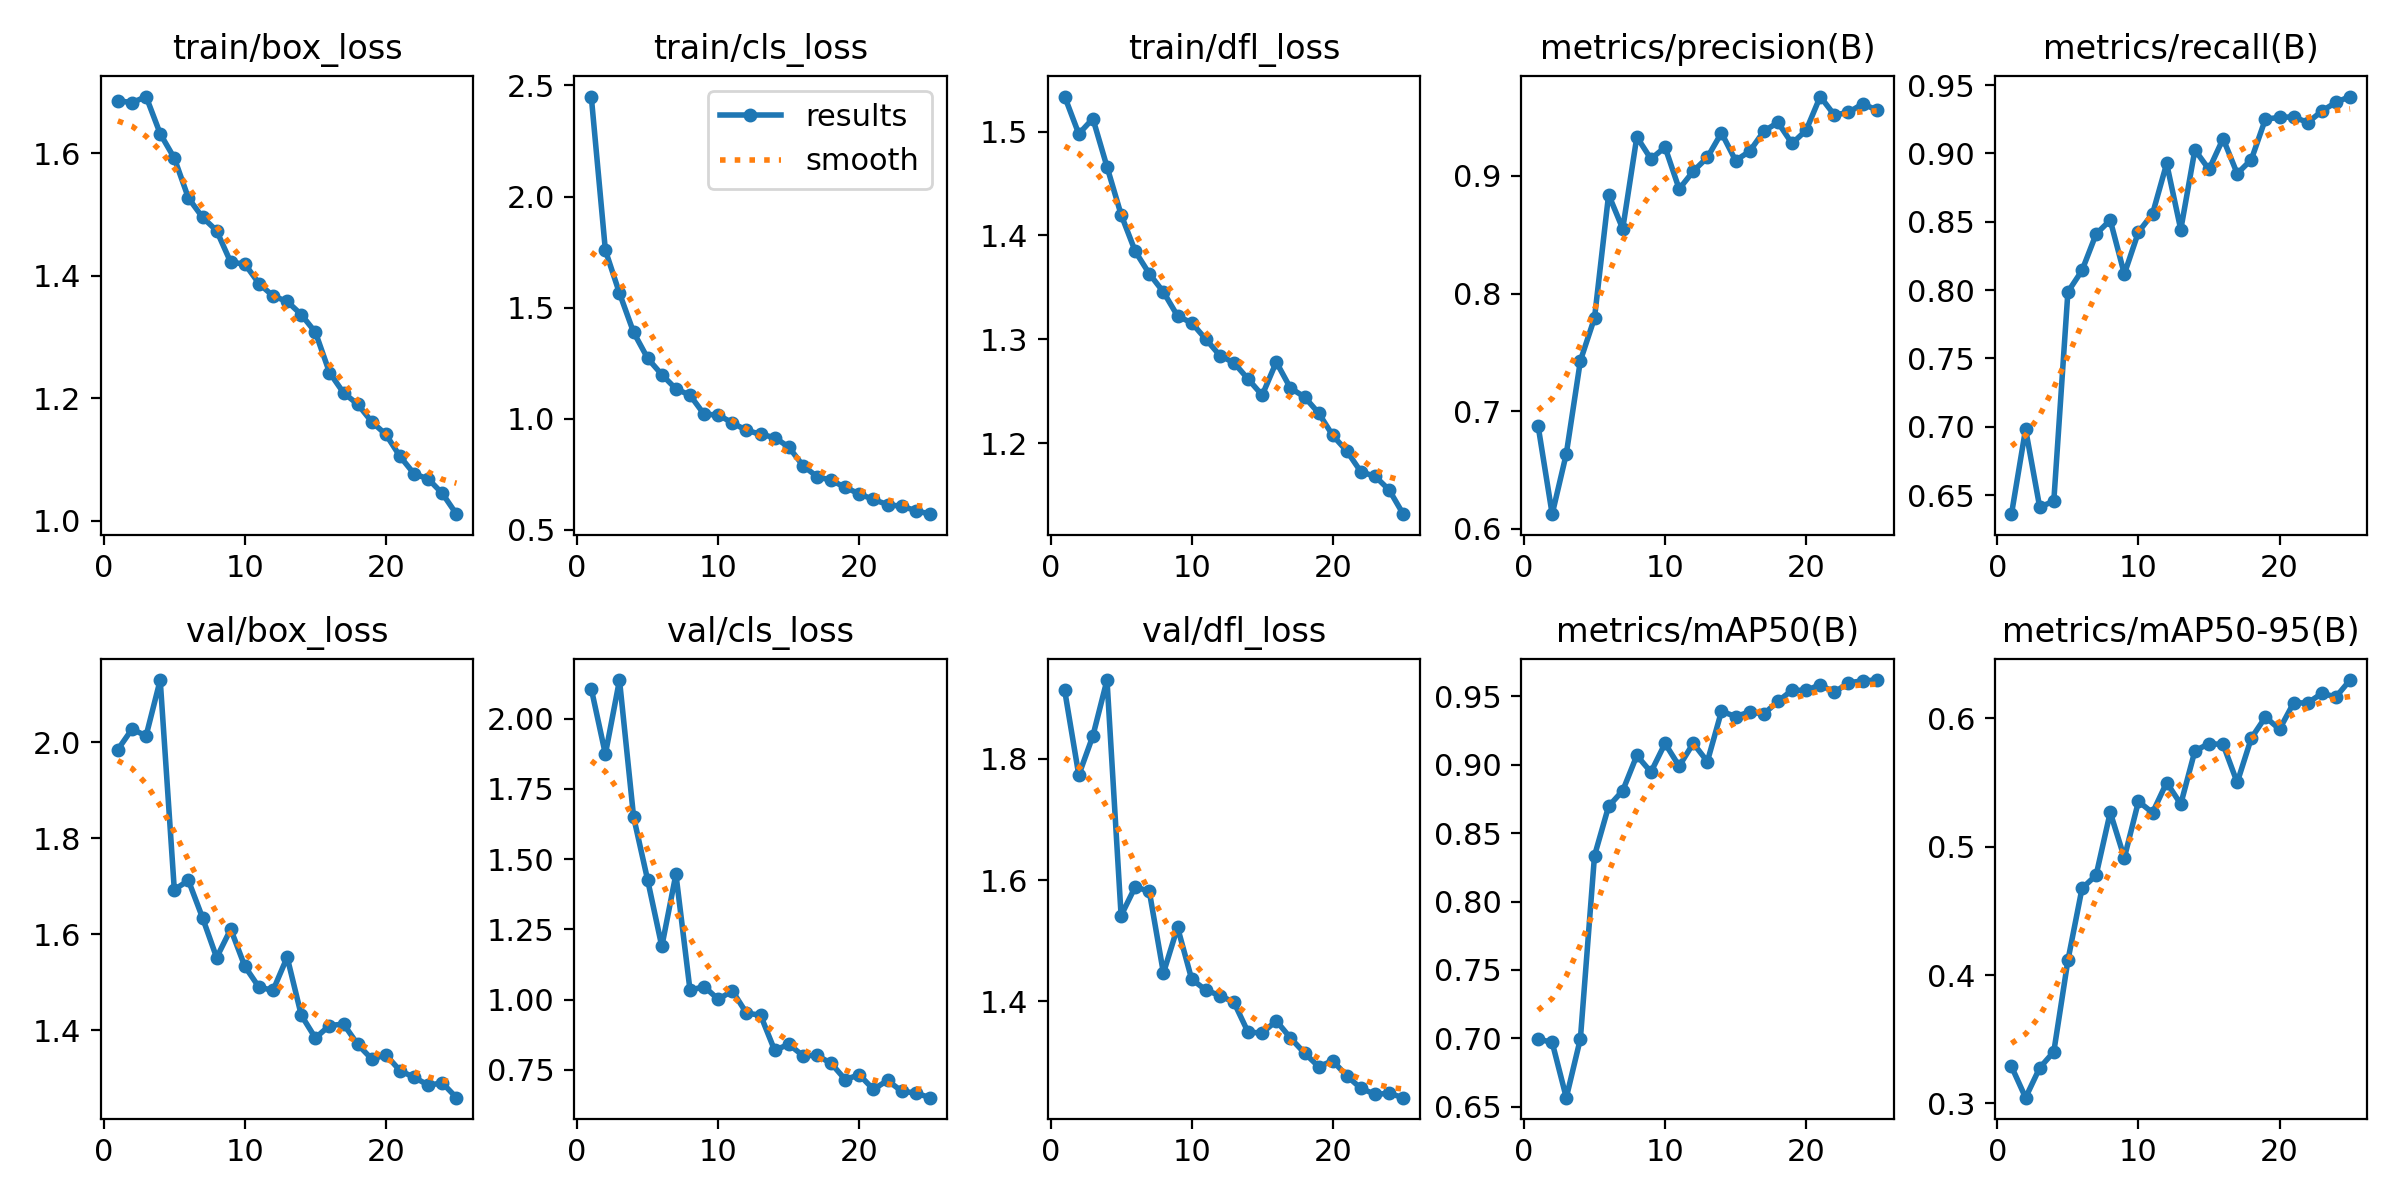

In [ ]:
# Validate the model on the test set
metrics = model.val()

print(f"Mean Average Precision (mAP50): {metrics.box.map50}")

# View training results (loss and accuracy plots)
from IPython.display import Image, display
display(Image(filename=f"{model.trainer.save_dir}/results.png", width=600))

**Here, in this dataset one logical mistake is there.There is two class in the dataset named Speed Bump and speedbump which contain same image,So i have merged 2 class into one class and re-trained the model**

In [ ]:
import yaml

with open(dataset_yaml, 'r') as f:
    data = yaml.safe_load(f)

print(f"Number of classes: {data['nc']}")
print(f"Class names: {data['names']}")

Number of classes: 2
Class names: ['Speed Bump', 'speedbump']


In [ ]:
import os

# Path to your training labels
label_path = os.path.join(dataset.location, "train/labels")
label_files = os.listdir(label_path)

classes_found = set()

# Read the first 100 label files to see what class IDs exist
for file in label_files[:100]:
    with open(os.path.join(label_path, file), 'r') as f:
        for line in f:
            class_id = line.split()[0]
            classes_found.add(class_id)

print(f"Class IDs found in your label files: {classes_found}")

Class IDs found in your label files: {'0', '1'}


In [ ]:
import os

# Define the paths to your label folders
paths = [
    os.path.join(dataset.location, "train/labels"),
    os.path.join(dataset.location, "valid/labels"),
    os.path.join(dataset.location, "test/labels")
]

for path in paths:
    if os.path.exists(path):
        for label_file in os.listdir(path):
            file_path = os.path.join(path, label_file)

            with open(file_path, 'r') as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.split()
                if len(parts) > 0:
                    # Change class ID 1 to 0
                    parts[0] = '0'
                    new_lines.append(" ".join(parts) + "\n")

            with open(file_path, 'w') as f:
                f.writelines(new_lines)

print("✅ All labels successfully merged into Class 0!")

✅ All labels successfully merged into Class 0!


**Re-trained with one class datatype**

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv11n model
model = YOLO('yolo11n.pt')

# Train the model
# data: path to your data.yaml
# epochs: number of training rounds
# imgsz: image size (standard is 640)
results = model.train(
    data=dataset_yaml,
    epochs=25,
    imgsz=640,
    plots=True,
    device=0 # Uses GPU
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/speed-breaker-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

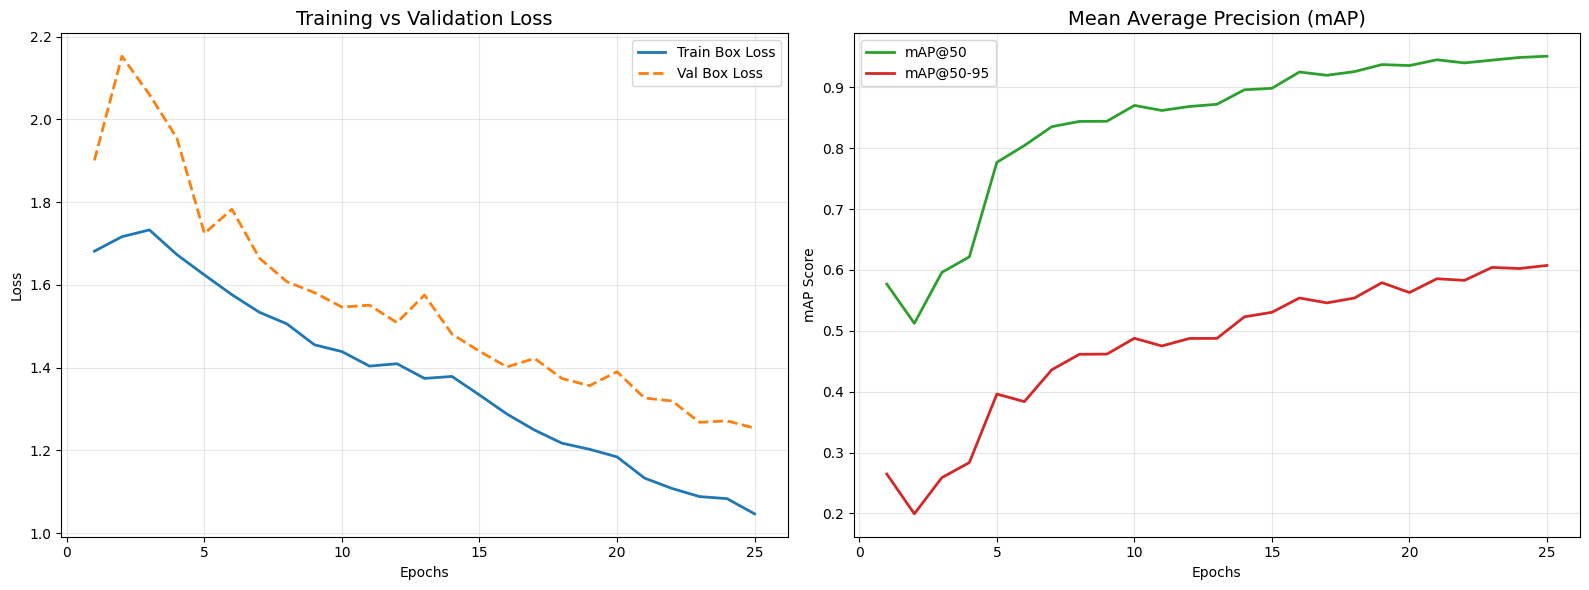

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your latest results
results_path = '/content/runs/detect/train/results.csv'
df = pd.read_csv(results_path)
df.columns = [c.strip() for c in df.columns]

# Create Figure
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Loss
ax[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='#1f77b4', linewidth=2)
ax[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='#ff7f0e', linestyle='--', linewidth=2)
ax[0].set_title('Training vs Validation Loss', fontsize=14)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Graph 2: Accuracy (mAP)
ax[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='#2ca02c', linewidth=2)
ax[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='#d62728', linewidth=2)
ax[1].set_title('Mean Average Precision (mAP)', fontsize=14)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('mAP Score')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- CONFUSION MATRIX.PNG ---


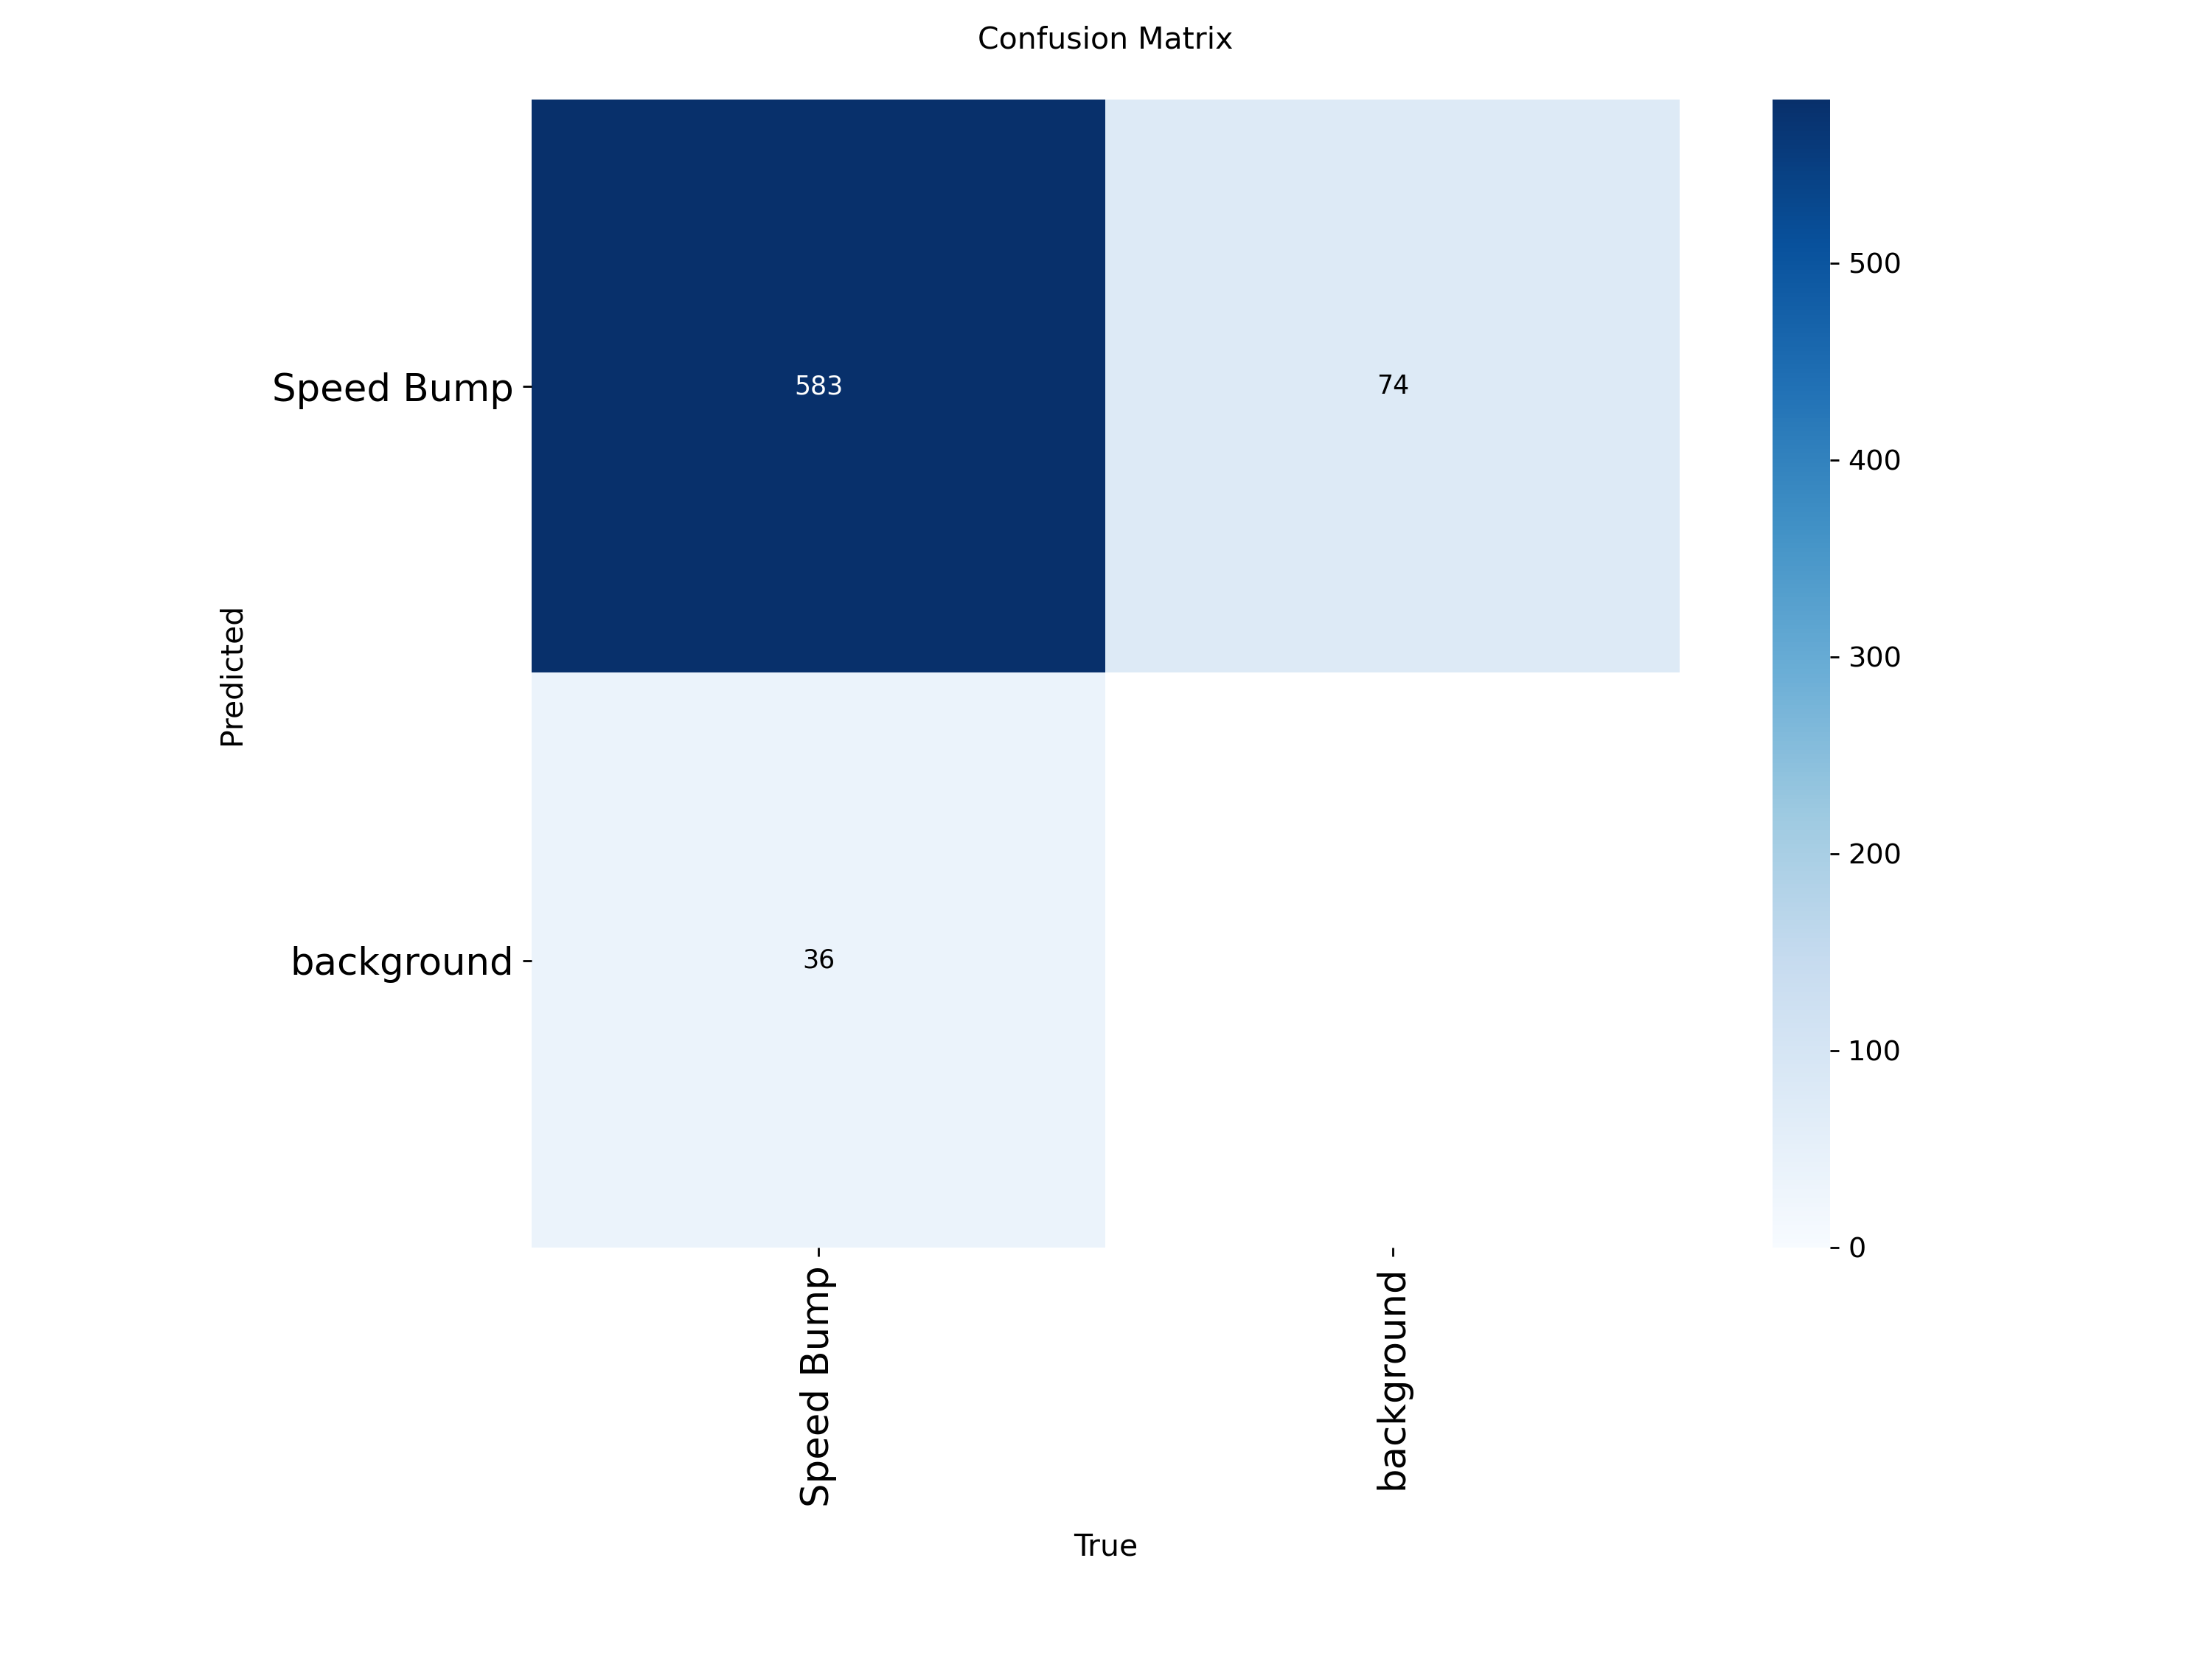

In [ ]:
from IPython.display import Image, display
import os

# List of visual results to show
visuals = [
    '/content/runs/detect/train/confusion_matrix.png',
    '/content/runs/detect/train/PR_curve.png',
    '/content/runs/detect/train/F1_curve.png'
]

for img in visuals:
    if os.path.exists(img):
        print(f"\n--- {img.split('/')[-1].replace('_', ' ').upper()} ---")
        display(Image(filename=img, width=700))

In [ ]:
import os
import glob
import cv2
from google.colab import files
from ultralytics import YOLO
from IPython.display import Video, display

# 1. Upload Video
print("Step 1: Upload your video file:")
uploaded = files.upload()
if not uploaded:
    print("No file uploaded.")
else:
    video_name = list(uploaded.keys())[0]
    output_raw_path = "processed_raw.mp4"

    # 2. Load Model
    model_path = '/content/runs/detect/train/weights/best.pt' # Using your specific weight name
    if not os.path.exists(model_path):
        print(f"Error: Model weights not found at {model_path}")
    else:
        model = YOLO(model_path)

        # 3. Open Video for Processing
        cap = cv2.VideoCapture(video_name)
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps    = int(cap.get(cv2.CAP_PROP_FPS))

        # Define Video Writer
        fourcc = cv2.VideoWriter_fourcc(*'MP4V')
        out = cv2.VideoWriter(output_raw_path, fourcc, fps, (width, height))

        print("Step 2: Processing frames and adding warnings...")

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Run YOLO detection
            results = model.predict(frame, conf=0.3, verbose=False)

            # Draw original YOLO detections
            annotated_frame = results[0].plot()

            # Custom Warning Logic
            # Check if any boxes were detected
            if len(results[0].boxes) > 0:
                # 1. Draw a Red Warning Banner at the top
                cv2.rectangle(annotated_frame, (0, 0), (width, 100), (0, 0, 255), -1)

                # 2. Add Warning Text
                cv2.putText(annotated_frame, "WARNING: SPEED BREAKER DETECTED", (int(width*0.1), 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3, cv2.LINE_AA)

                # 3. Add Slow Down Instruction
                cv2.putText(annotated_frame, ">>> SLOW DOWN SPEED NOW <<<", (int(width*0.2), 85),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 0), 2, cv2.LINE_AA)

            out.write(annotated_frame)

        cap.release()
        out.release()

        # 4. Convert to Web-Friendly MP4
        final_output = "speed_breaker_warning_final.mp4"
        print("Step 3: Finalizing video format...")
        !ffmpeg -i "{output_raw_path}" -vcodec libx264 -f mp4 "{final_output}" -y -loglevel quiet

        # 5. Show and Download Result
        print("\n--- DETECTION WITH ACTIVE WARNING SYSTEM ---")
        display(Video(final_output, embed=True, width=800))
        files.download(final_output)